In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Environment ready")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Environment ready
Pandas: 3.0.5
NumPy: 2.4.6
Scikit-learn: 1.9.1


In [136]:
import os

data_path = "../data/raw"

print("Files available:")
for file in os.listdir(data_path):
    print("-", file)

Files available:
- holidays_events.csv
- oil.csv
- sample_submission.csv
- stores.csv
- test.csv
- train.csv
- transactions.csv


In [137]:
train = pd.read_csv("../data/raw/train.csv")

print("Dataset loaded successfully!")
print("Shape:", train.shape)

Dataset loaded successfully!
Shape: (3000888, 6)


In [138]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [139]:
print("Columns:")
print(train.columns.tolist())

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']


In [140]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [141]:
train.isnull().sum()


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [142]:
train.duplicated().sum()

np.int64(0)

In [143]:
train.dtypes

id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object

In [144]:
pd.options.display.float_format = "{:,.2f}".format

In [145]:
train.describe()

,id,store_nbr,sales,onpromotion
count,"3,000,888.00","3,000,888.00","3,000,888.00","3,000,888.00"
mean,"1,500,443.50",27.50,357.78,2.60
std,"866,281.89",15.59,"1,102.00",12.22
min,0.00,1.00,0.00,0.00
25%,"750,221.75",14.00,0.00,0.00
50%,"1,500,443.50",27.50,11.00,0.00
75%,"2,250,665.25",41.00,195.85,0.00
max,"3,000,887.00",54.00,"124,717.00",741.00


In [146]:
print("Stores:", train["store_nbr"].nunique())
print("Product families:", train["family"].nunique())
print("Date range:", train["date"].min(), "to", train["date"].max())

Stores: 54
Product families: 33
Date range: 2013-01-01 to 2017-08-15


In [147]:
print("Minimum sales:", train["sales"].min())
print("Maximum sales:", train["sales"].max())
print("Average sales:", train["sales"].mean())

Minimum sales: 0.0
Maximum sales: 124717.0
Average sales: 357.77574911261877


In [148]:
print("Zero-sales records:", (train["sales"] == 0).sum())

Zero-sales records: 939130


In [149]:
train["date"] = pd.to_datetime(train["date"])

train = train.sort_values("date").reset_index(drop=True)

print(train.dtypes)
print("\nDate range:")
print(train["date"].min(), "to", train["date"].max())

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

Date range:
2013-01-01 00:00:00 to 2017-08-15 00:00:00


In [150]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

daily_sales.columns = ["date", "total_sales"]

print(daily_sales.head())
print("\nNumber of days:", len(daily_sales))
print("Date range:", daily_sales["date"].min(), "to", daily_sales["date"].max())

        date  total_sales
0 2013-01-01     2,511.62
1 2013-01-02   496,092.42
2 2013-01-03   361,461.23
3 2013-01-04   354,459.68
4 2013-01-05   477,350.12

Number of days: 1684
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


In [151]:
print("Daily Sales Statistics:")
print(daily_sales["total_sales"].describe())

print("\nLowest 10 sales days:")
print(daily_sales.nsmallest(10, "total_sales"))

print("\nHighest 10 sales days:")
print(daily_sales.nlargest(10, "total_sales"))

Daily Sales Statistics:
count       1,684.00
mean      637,556.38
std       234,410.24
min         2,511.62
25%       442,711.49
50%       632,188.86
75%       785,945.48
max     1,463,083.96
Name: total_sales, dtype: float64

Lowest 10 sales days:
           date  total_sales
0    2013-01-01     2,511.62
364  2014-01-01     8,602.07
1457 2017-01-01    12,082.50
728  2015-01-01    12,773.62
1092 2016-01-01    16,433.39
23   2013-01-24   247,245.69
72   2013-03-14   247,541.42
9    2013-01-10   258,982.00
28   2013-01-29   264,488.82
177  2013-06-27   266,525.46

Highest 10 sales days:
           date  total_sales
1547 2017-04-01 1,463,083.96
1458 2017-01-02 1,402,306.37
1611 2017-06-04 1,376,511.52
1200 2016-04-18 1,345,920.60
1577 2017-05-01 1,306,699.37
1639 2017-07-02 1,296,379.22
1449 2016-12-23 1,282,145.52
1430 2016-12-04 1,276,195.04
1199 2016-04-17 1,271,833.74
1213 2016-05-01 1,270,121.21


### Visualize Overall Sales Trend


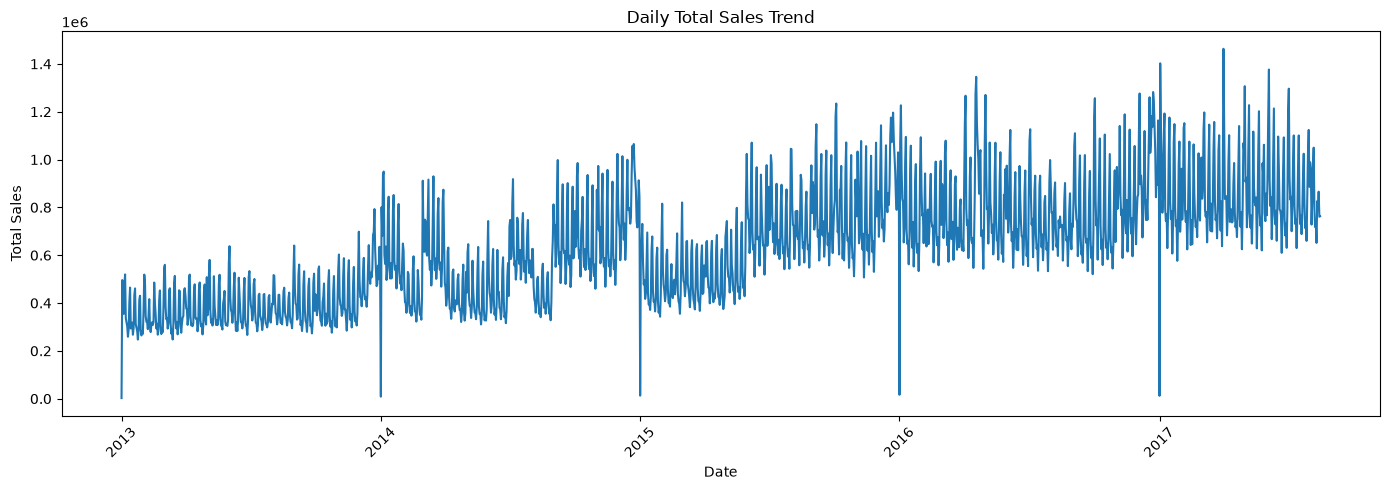

Figure saved successfully.


In [204]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"]
)

plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/overall_daily_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Monthly Sales Trend

In [153]:
monthly_sales = (
    daily_sales
    .set_index("date")
    .resample("ME")["total_sales"]
    .sum()
    .reset_index()
)

print(monthly_sales.head())
print("\nNumber of months:", len(monthly_sales))

        date   total_sales
0 2013-01-31 10,327,624.74
1 2013-02-28  9,658,959.78
2 2013-03-31 11,428,497.04
3 2013-04-30 10,993,464.74
4 2013-05-31 11,597,704.01

Number of months: 56


### Visualize Monthly Sales Trend

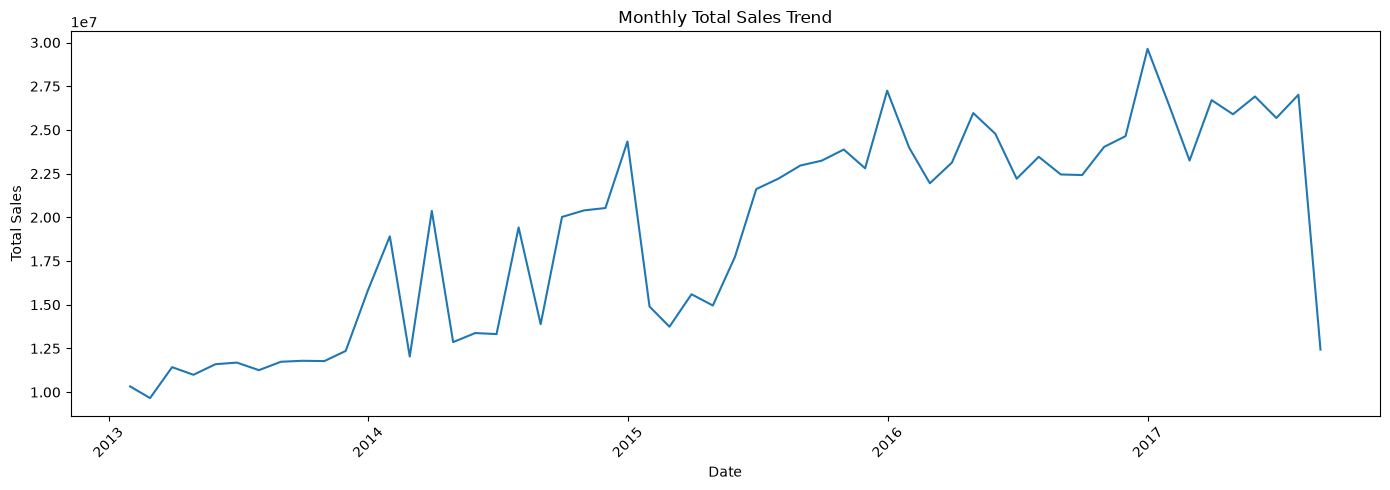

Figure saved successfully.


In [205]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["total_sales"]
)

plt.title("Monthly Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Weekly Seasonality

In [155]:
daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales = (
    daily_sales.groupby("day_of_week")["total_sales"]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

print(weekday_sales)

  day_of_week  total_sales
0      Monday   617,542.71
1     Tuesday   569,926.09
2   Wednesday   593,244.55
3    Thursday   505,269.20
4      Friday   579,574.36
5    Saturday   772,205.59
6      Sunday   825,218.12


### Visualize Sales by Day of Week

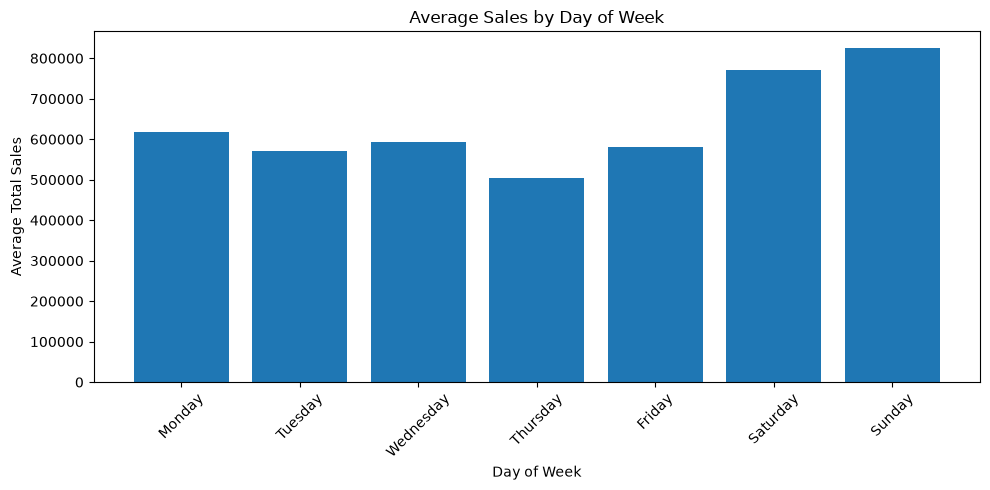

Figure saved successfully.


In [206]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales["day_of_week"],
    weekday_sales["total_sales"]
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/weekly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Monthly Seasonality

In [157]:
daily_sales["month"] = daily_sales["date"].dt.month

monthly_avg = (
    daily_sales.groupby("month")["total_sales"]
    .mean()
    .reset_index()
)

print(monthly_avg)

    month  total_sales
0       1   609,304.21
1       2   571,895.24
2       3   627,280.56
3       4   604,454.12
4       5   609,026.69
5       6   630,111.36
6       7   666,858.46
7       8   600,520.70
8       9   645,614.00
9      10   645,809.51
10     11   669,464.90
11     12   808,565.34


### Visualize Average Sales by Month

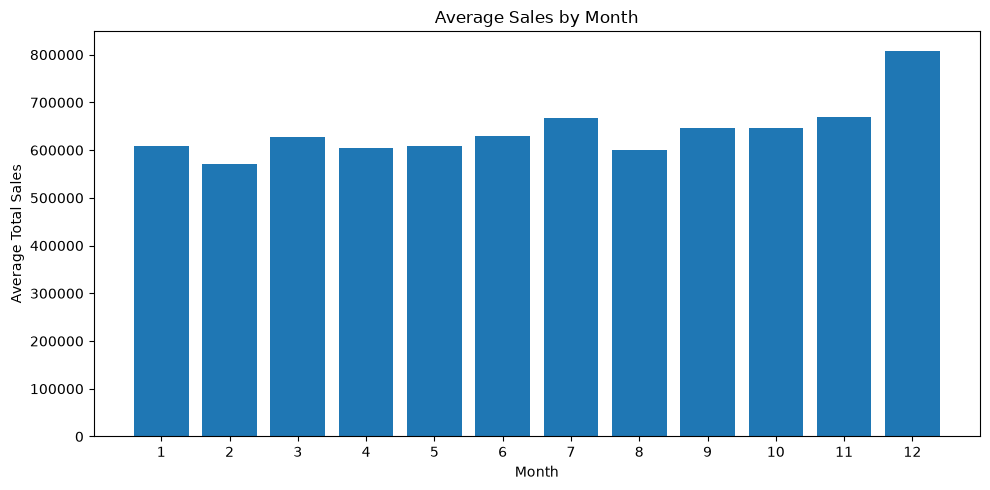

Figure saved successfully.


In [207]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_avg["month"],
    monthly_avg["total_sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Total Sales")
plt.xticks(range(1, 13))

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Promotion Impact on Sales

In [159]:
daily_promo = (
    train.groupby("date")["onpromotion"]
    .sum()
    .reset_index()
)

daily_promo.columns = ["date", "total_promotions"]

print(daily_promo.head())
print("\nPromotion statistics:")
print(daily_promo["total_promotions"].describe())

        date  total_promotions
0 2013-01-01                 0
1 2013-01-02                 0
2 2013-01-03                 0
3 2013-01-04                 0
4 2013-01-05                 0

Promotion statistics:
count    1,684.00
mean     4,638.14
std      5,418.62
min          0.00
25%          0.00
50%      2,300.00
75%      8,397.25
max     26,861.00
Name: total_promotions, dtype: float64


In [160]:
promo_sales = daily_sales.merge(
    daily_promo,
    on="date",
    how="left"
)

print(promo_sales.head())

        date  total_sales day_of_week  month  total_promotions
0 2013-01-01     2,511.62     Tuesday      1                 0
1 2013-01-02   496,092.42   Wednesday      1                 0
2 2013-01-03   361,461.23    Thursday      1                 0
3 2013-01-04   354,459.68      Friday      1                 0
4 2013-01-05   477,350.12    Saturday      1                 0


In [161]:
print(
    promo_sales[["total_sales", "total_promotions"]]
    .corr()
)

                  total_sales  total_promotions
total_sales              1.00              0.57
total_promotions         0.57              1.00


### Visualize Promotion vs Sales

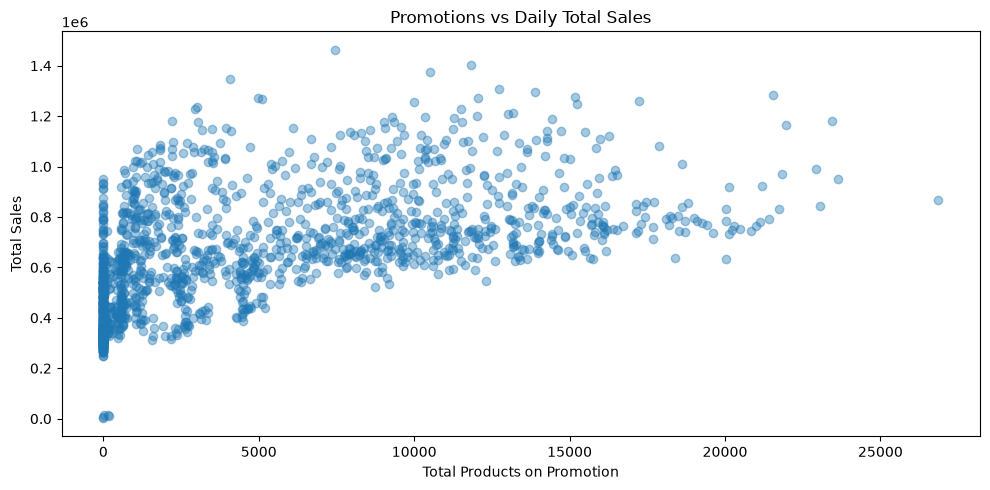

Figure saved successfully.


In [208]:
plt.figure(figsize=(10, 5))

plt.scatter(
    promo_sales["total_promotions"],
    promo_sales["total_sales"],
    alpha=0.4
)

plt.title("Promotions vs Daily Total Sales")
plt.xlabel("Total Products on Promotion")
plt.ylabel("Total Sales")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/promotion_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Holiday Impact on Sales

In [163]:
holidays = pd.read_csv("../data/raw/holidays_events.csv")

holidays["date"] = pd.to_datetime(holidays["date"])

print(holidays.head())

print("\nHoliday Types:")
print(holidays["type"].value_counts())

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  

Holiday Types:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64


### Analyze Holiday Effect on Daily Sales

In [164]:
holiday_dates = holidays[["date", "type"]].drop_duplicates()

holiday_sales = daily_sales.merge(
    holiday_dates,
    on="date",
    how="left"
)

holiday_sales["is_holiday"] = holiday_sales["type"].notna()

print(holiday_sales[["date", "total_sales", "type", "is_holiday"]].head(10))

print("\nAverage Sales:")
print(
    holiday_sales.groupby("is_holiday")["total_sales"].mean()
)

        date  total_sales      type  is_holiday
0 2013-01-01     2,511.62   Holiday        True
1 2013-01-02   496,092.42       NaN       False
2 2013-01-03   361,461.23       NaN       False
3 2013-01-04   354,459.68       NaN       False
4 2013-01-05   477,350.12  Work Day        True
5 2013-01-06   519,695.40       NaN       False
6 2013-01-07   336,122.80       NaN       False
7 2013-01-08   318,347.78       NaN       False
8 2013-01-09   302,530.81       NaN       False
9 2013-01-10   258,982.00       NaN       False

Average Sales:
is_holiday
False   627,547.66
True    703,085.33
Name: total_sales, dtype: float64


### Visualize Holiday vs Non-Holiday Sales

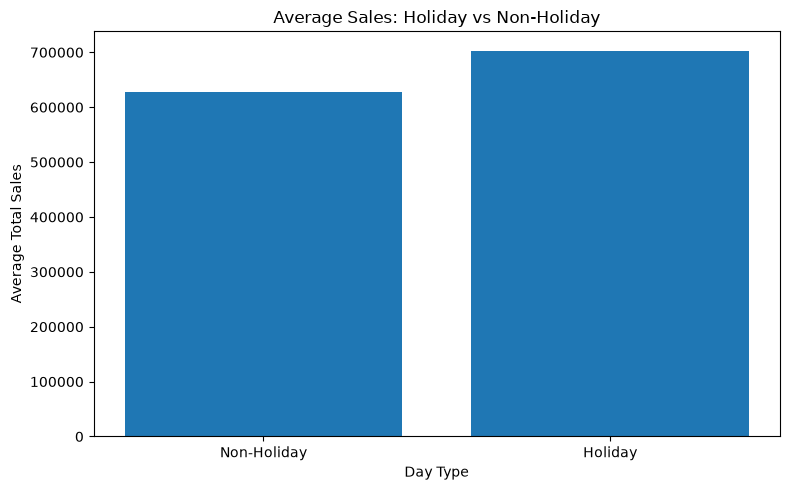

Figure saved successfully.


In [209]:
holiday_avg = (
    holiday_sales.groupby("is_holiday")["total_sales"]
    .mean()
    .reset_index()
)

holiday_avg["category"] = holiday_avg["is_holiday"].map({
    False: "Non-Holiday",
    True: "Holiday"
})

plt.figure(figsize=(8, 5))

plt.bar(
    holiday_avg["category"],
    holiday_avg["total_sales"]
)

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Day Type")
plt.ylabel("Average Total Sales")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/holiday_vs_nonholiday_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Oil Price and Sales Relationship

In [166]:
oil = pd.read_csv("../data/raw/oil.csv")

oil["date"] = pd.to_datetime(oil["date"])

print(oil.head())
print("\nMissing Values:")
print(oil.isnull().sum())

sales_oil = daily_sales.merge(
    oil,
    on="date",
    how="left"
)

print("\nSales and Oil Data:")
print(sales_oil.head())

print("\nCorrelation:")
print(
    sales_oil[["total_sales", "dcoilwtico"]].corr()
)

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20

Missing Values:
date           0
dcoilwtico    43
dtype: int64

Sales and Oil Data:
        date  total_sales day_of_week  month  dcoilwtico
0 2013-01-01     2,511.62     Tuesday      1         NaN
1 2013-01-02   496,092.42   Wednesday      1       93.14
2 2013-01-03   361,461.23    Thursday      1       92.97
3 2013-01-04   354,459.68      Friday      1       93.12
4 2013-01-05   477,350.12    Saturday      1         NaN

Correlation:
             total_sales  dcoilwtico
total_sales         1.00       -0.71
dcoilwtico         -0.71        1.00


### Visualize Oil Price vs Sales

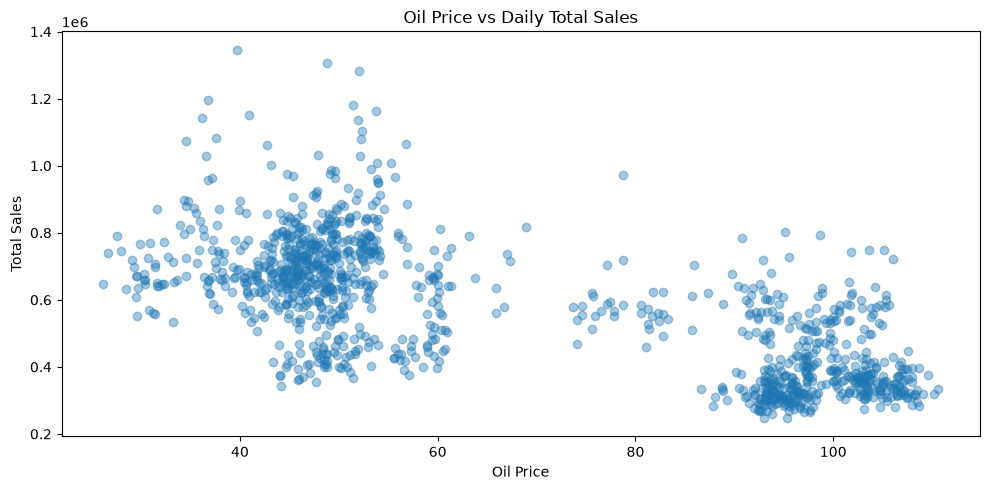

Figure saved successfully.


In [210]:
plt.figure(figsize=(10, 5))

plt.scatter(
    sales_oil["dcoilwtico"],
    sales_oil["total_sales"],
    alpha=0.4
)

plt.title("Oil Price vs Daily Total Sales")
plt.xlabel("Oil Price")
plt.ylabel("Total Sales")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/oil_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")


### Create Time-Based Features

In [168]:
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["quarter"] = daily_sales["date"].dt.quarter
daily_sales["day"] = daily_sales["date"].dt.day
daily_sales["day_of_week_num"] = daily_sales["date"].dt.dayofweek
daily_sales["is_weekend"] = daily_sales["day_of_week_num"].isin([5, 6]).astype(int)

print(daily_sales.head())

        date  total_sales day_of_week  month  year  quarter  day  \
0 2013-01-01     2,511.62     Tuesday      1  2013        1    1   
1 2013-01-02   496,092.42   Wednesday      1  2013        1    2   
2 2013-01-03   361,461.23    Thursday      1  2013        1    3   
3 2013-01-04   354,459.68      Friday      1  2013        1    4   
4 2013-01-05   477,350.12    Saturday      1  2013        1    5   

   day_of_week_num  is_weekend  
0                1           0  
1                2           0  
2                3           0  
3                4           0  
4                5           1  


### Create Lag Features

In [169]:
daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

daily_sales["lag_1"] = daily_sales["total_sales"].shift(1)
daily_sales["lag_7"] = daily_sales["total_sales"].shift(7)
daily_sales["lag_14"] = daily_sales["total_sales"].shift(14)
daily_sales["lag_30"] = daily_sales["total_sales"].shift(30)

print(daily_sales[[
    "date",
    "total_sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30"
]].head(35))

         date  total_sales      lag_1      lag_7     lag_14     lag_30
0  2013-01-01     2,511.62        NaN        NaN        NaN        NaN
1  2013-01-02   496,092.42   2,511.62        NaN        NaN        NaN
2  2013-01-03   361,461.23 496,092.42        NaN        NaN        NaN
3  2013-01-04   354,459.68 361,461.23        NaN        NaN        NaN
4  2013-01-05   477,350.12 354,459.68        NaN        NaN        NaN
5  2013-01-06   519,695.40 477,350.12        NaN        NaN        NaN
6  2013-01-07   336,122.80 519,695.40        NaN        NaN        NaN
7  2013-01-08   318,347.78 336,122.80   2,511.62        NaN        NaN
8  2013-01-09   302,530.81 318,347.78 496,092.42        NaN        NaN
9  2013-01-10   258,982.00 302,530.81 361,461.23        NaN        NaN
10 2013-01-11   289,737.69 258,982.00 354,459.68        NaN        NaN
11 2013-01-12   403,258.21 289,737.69 477,350.12        NaN        NaN
12 2013-01-13   464,638.55 403,258.21 519,695.40        NaN        NaN
13 201

### Create Rolling Average Features

In [170]:
daily_sales["rolling_mean_7"] = (
    daily_sales["total_sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_sales["rolling_mean_14"] = (
    daily_sales["total_sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

daily_sales["rolling_mean_30"] = (
    daily_sales["total_sales"]
    .shift(1)
    .rolling(30)
    .mean()
)

print(daily_sales[[
    "date",
    "total_sales",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]].head(35))

         date  total_sales  rolling_mean_7  rolling_mean_14  rolling_mean_30
0  2013-01-01     2,511.62             NaN              NaN              NaN
1  2013-01-02   496,092.42             NaN              NaN              NaN
2  2013-01-03   361,461.23             NaN              NaN              NaN
3  2013-01-04   354,459.68             NaN              NaN              NaN
4  2013-01-05   477,350.12             NaN              NaN              NaN
5  2013-01-06   519,695.40             NaN              NaN              NaN
6  2013-01-07   336,122.80             NaN              NaN              NaN
7  2013-01-08   318,347.78      363,956.18              NaN              NaN
8  2013-01-09   302,530.81      409,075.63              NaN              NaN
9  2013-01-10   258,982.00      381,423.97              NaN              NaN
10 2013-01-11   289,737.69      366,784.08              NaN              NaN
11 2013-01-12   403,258.21      357,538.09              NaN              NaN

### Prepare Final Modeling Dataset

In [203]:
# Create and save the processed modeling dataset

model_data = daily_sales.dropna().copy()

print("Original rows:", len(daily_sales))
print("Modeling rows:", len(model_data))

print("\nMissing values:")
print(model_data.isnull().sum())

print("\nModeling dataset shape:", model_data.shape)

# Save processed dataset
model_data.to_csv(
    "../data/processed/daily_sales_model_data.csv",
    index=False
)

print("\nProcessed modeling dataset saved successfully.")
print("File: data/processed/daily_sales_model_data.csv")

Original rows: 1684
Modeling rows: 1654

Missing values:
date               0
total_sales        0
day_of_week        0
month              0
year               0
quarter            0
day                0
day_of_week_num    0
is_weekend         0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
dtype: int64

Modeling dataset shape: (1654, 16)

Processed modeling dataset saved successfully.
File: data/processed/daily_sales_model_data.csv


### Create Time-Based Train-Test Split

In [172]:
split_date = "2017-01-01"

train_data = model_data[model_data["date"] < split_date].copy()
test_data = model_data[model_data["date"] >= split_date].copy()

print("Training period:", train_data["date"].min(), "to", train_data["date"].max())
print("Testing period:", test_data["date"].min(), "to", test_data["date"].max())

print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period: 2013-01-31 00:00:00 to 2016-12-31 00:00:00
Testing period: 2017-01-01 00:00:00 to 2017-08-15 00:00:00

Training rows: 1427
Testing rows: 227


### Select Features and Target Variable

In [173]:
features = [
    "year",
    "month",
    "quarter",
    "day",
    "day_of_week_num",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

X_train = train_data[features]
y_train = train_data["total_sales"]

X_test = test_data[features]
y_test = test_data["total_sales"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1427, 13)
X_test shape: (227, 13)
y_train shape: (1427,)
y_test shape: (227,)


### Train Baseline Linear Regression Model

In [174]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Evaluate Linear Regression Model

In [175]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, linear_predictions)
rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
mape = np.mean(
    np.abs((y_test - linear_predictions) / y_test)
) * 100

print("Linear Regression Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


Linear Regression Performance:
MAE : 83290.98334445679
RMSE: 141134.3954052065
MAPE: 49.634470708827855 %


### Train Random Forest Regression Model

In [176]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Evaluate Random Forest Model


In [177]:
mae_rf = mean_absolute_error(y_test, rf_predictions)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

mape_rf = np.mean(
    np.abs((y_test - rf_predictions) / y_test)
) * 100

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf, "%")

Random Forest Performance:
MAE : 76821.41951086377
RMSE: 133556.95920379958
MAPE: 47.503538759941804 %


## Compare


In [178]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "MAPE (%)": [mape, mape_rf]
})

print(results)

               Model       MAE       RMSE  MAPE (%)
0  Linear Regression 83,290.98 141,134.40     49.63
1      Random Forest 76,821.42 133,556.96     47.50


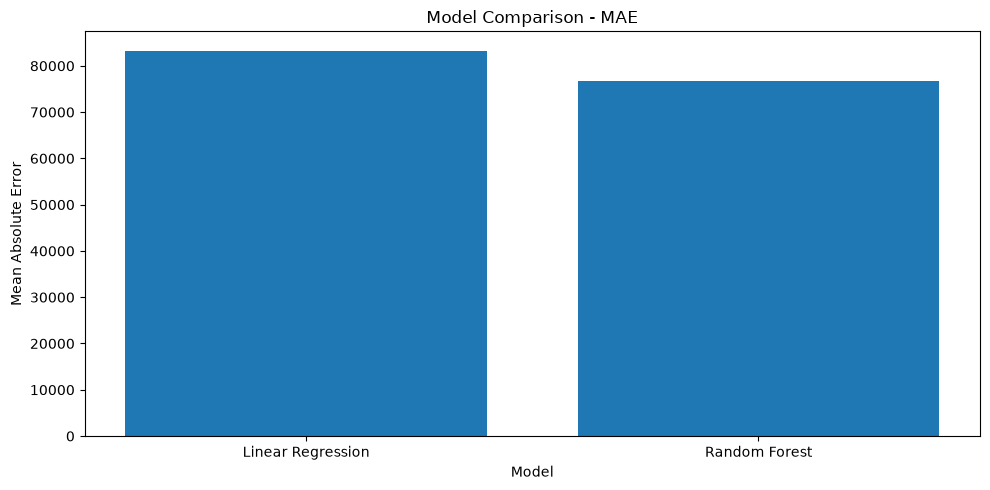

Figure saved successfully.


In [211]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Visualize Actual vs Predicted Sales

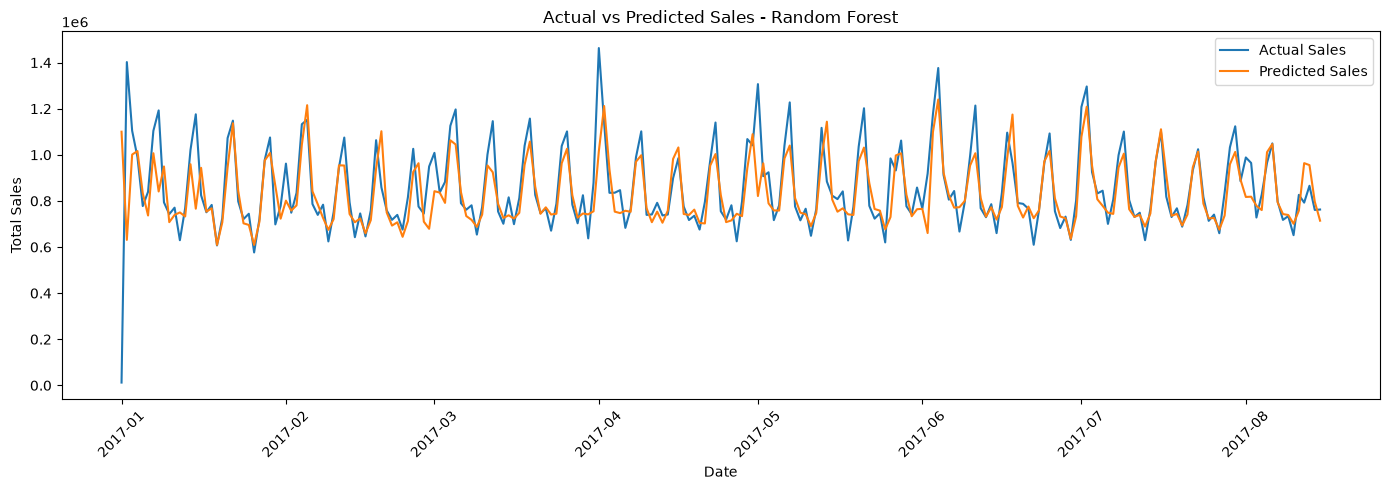

Figure saved successfully.


In [212]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data["date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    test_data["date"],
    rf_predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Prediction Errors

In [181]:
prediction_errors = y_test.values - rf_predictions

print("Prediction Error Statistics:")
print(pd.Series(prediction_errors).describe())

Prediction Error Statistics:
count          227.00
mean        22,913.10
std        131,867.57
min     -1,088,199.90
25%        -32,833.81
50%         16,578.60
75%         67,930.44
max        771,269.64
dtype: float64


### Visualize Prediction Errors

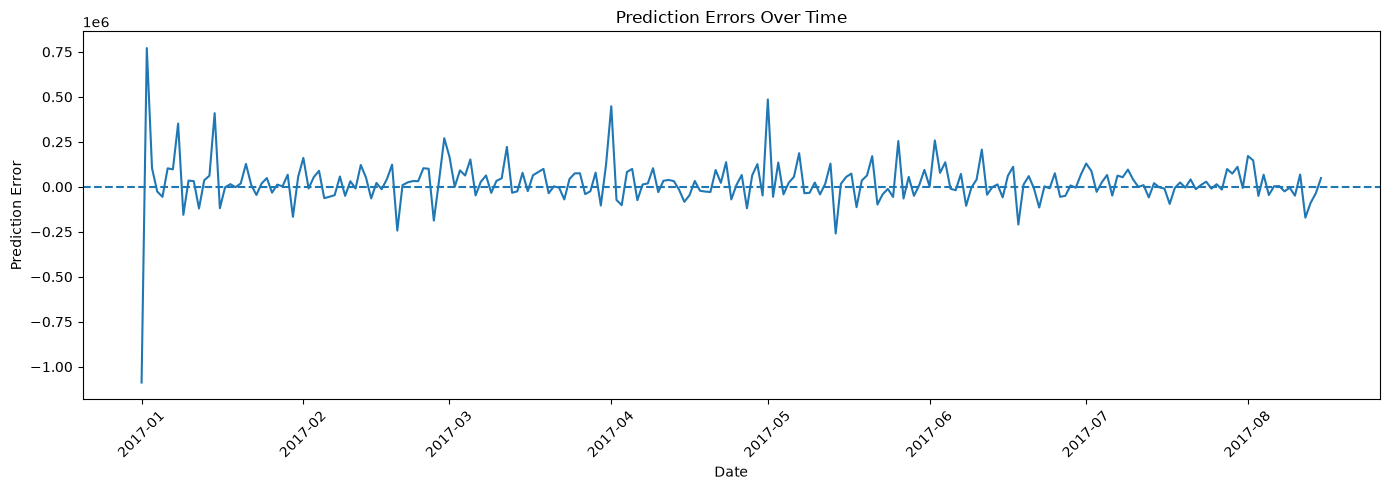

Figure saved successfully.


In [213]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data["date"],
    prediction_errors
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Prediction Errors Over Time")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/prediction_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Analyze Feature Importance

In [183]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance Score": rf_model.feature_importances_
}).sort_values(
    "Importance Score",
    ascending=False
).reset_index(drop=True)

# Add ranking
feature_importance.insert(
    0,
    "Rank",
    range(1, len(feature_importance) + 1)
)

# Convert importance into percentage
feature_importance["Importance Percentage"] = (
    feature_importance["Importance Score"] * 100
).round(2)

# Add business interpretation
feature_meaning = {
    "year": "Captures long-term yearly changes in sales demand.",
    "month": "Captures monthly seasonal demand patterns.",
    "quarter": "Represents broader quarterly seasonal effects.",
    "day": "Captures changes in demand across calendar days.",
    "day_of_week_num": "Captures recurring weekly sales patterns.",
    "is_weekend": "Identifies differences between weekday and weekend demand.",
    "lag_1": "Previous day's sales, capturing very recent demand.",
    "lag_7": "Sales from the previous week, capturing weekly demand patterns.",
    "lag_14": "Sales from two weeks earlier, capturing recurring demand.",
    "lag_30": "Sales from approximately one month earlier.",
    "rolling_mean_7": "Recent 7-day average demand, reducing short-term fluctuations.",
    "rolling_mean_14": "Recent 14-day average demand, capturing medium-term trends.",
    "rolling_mean_30": "Recent 30-day average demand, capturing broader demand trends."
}

feature_importance["Business Interpretation"] = (
    feature_importance["Feature"]
    .map(feature_meaning)
)

print("Feature Importance Analysis:")
display(feature_importance.round(4))

Feature Importance Analysis:


,Rank,Feature,Importance Score,Importance Percentage,Business Interpretation
0,1,lag_7,0.52,51.97,"Sales from the previous week, capturing weekly..."
1,2,lag_14,0.14,13.86,"Sales from two weeks earlier, capturing recurr..."
2,3,lag_1,0.11,11.10,"Previous day's sales, capturing very recent de..."
3,4,rolling_mean_7,0.08,8.28,"Recent 7-day average demand, reducing short-te..."
4,5,day,0.04,4.18,Captures changes in demand across calendar days.
5,6,day_of_week_num,0.03,3.30,Captures recurring weekly sales patterns.
6,7,is_weekend,0.02,1.82,Identifies differences between weekday and wee...
7,8,lag_30,0.01,1.40,Sales from approximately one month earlier.
8,9,month,0.01,1.38,Captures monthly seasonal demand patterns.
9,10,rolling_mean_14,0.01,1.32,"Recent 14-day average demand, capturing medium..."


### Visualize Feature Importance

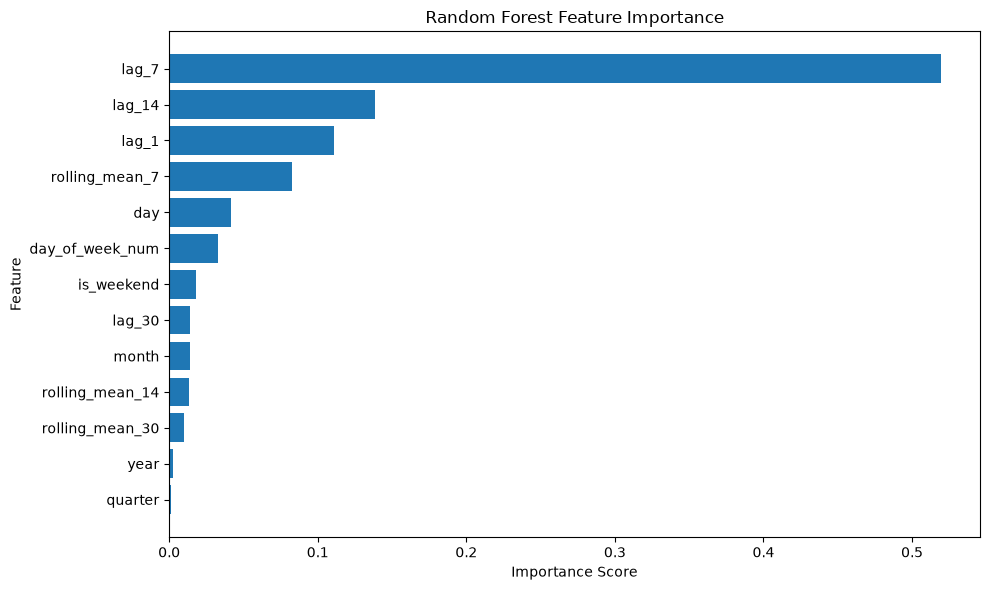

Figure saved successfully.


In [214]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance Score"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Prepare Final Forecast Dataset

In [185]:
forecast_data = pd.DataFrame({
    "date": test_data["date"].values,
    "actual_sales": y_test.values,
    "predicted_sales": rf_predictions
})

forecast_data["error"] = (
    forecast_data["actual_sales"]
    - forecast_data["predicted_sales"]
)

print("Forecast Dataset:")
print(forecast_data.head())

print("\nShape:", forecast_data.shape)

Forecast Dataset:
        date  actual_sales  predicted_sales         error
0 2017-01-01     12,082.50     1,100,282.40 -1,088,199.90
1 2017-01-02  1,402,306.37       631,036.74    771,269.64
2 2017-01-03  1,104,377.08     1,001,096.43    103,280.65
3 2017-01-04    990,093.46     1,016,256.75    -26,163.29
4 2017-01-05    777,620.95       833,487.72    -55,866.77

Shape: (227, 4)


### Generate Future Sales Forecast

In [186]:
history = daily_sales[["date", "total_sales"]].copy()

future_dates = pd.date_range(
    start=history["date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_predictions = []

for date in future_dates:

    values = history["total_sales"].tolist()

    row = {
        "year": date.year,
        "month": date.month,
        "quarter": date.quarter,
        "day": date.day,
        "day_of_week_num": date.dayofweek,
        "is_weekend": int(date.dayofweek in [5, 6]),
        "lag_1": values[-1],
        "lag_7": values[-7],
        "lag_14": values[-14],
        "lag_30": values[-30],
        "rolling_mean_7": np.mean(values[-7:]),
        "rolling_mean_14": np.mean(values[-14:]),
        "rolling_mean_30": np.mean(values[-30:])
    }

    row_df = pd.DataFrame([row])
    prediction = rf_model.predict(row_df[features])[0]

    future_predictions.append(prediction)

    history = pd.concat([
        history,
        pd.DataFrame({
            "date": [date],
            "total_sales": [prediction]
        })
    ], ignore_index=True)

future_forecast = pd.DataFrame({
    "date": future_dates,
    "forecasted_sales": future_predictions
})

# Add business-friendly information
future_forecast["day_of_week"] = future_forecast["date"].dt.day_name()
future_forecast["day_type"] = np.where(
    future_forecast["date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

future_forecast["previous_day_sales"] = (
    [daily_sales["total_sales"].iloc[-1]] +
    future_predictions[:-1]
)

future_forecast["change_from_previous_day"] = (
    future_forecast["forecasted_sales"] -
    future_forecast["previous_day_sales"]
)

future_forecast["change_percentage"] = (
    future_forecast["change_from_previous_day"] /
    future_forecast["previous_day_sales"]
) * 100

future_forecast["7_day_moving_average"] = (
    future_forecast["forecasted_sales"]
    .rolling(window=7, min_periods=1)
    .mean()
)

future_forecast["forecast_rank"] = (
    future_forecast["forecasted_sales"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Reorder columns for business readability
future_forecast = future_forecast[
    [
        "date",
        "day_of_week",
        "day_type",
        "forecasted_sales",
        "previous_day_sales",
        "change_from_previous_day",
        "change_percentage",
        "7_day_moving_average",
        "forecast_rank"
    ]
]

print("Next 30 Days Sales Forecast:")
display(future_forecast.round(2))

Next 30 Days Sales Forecast:


C:\Users\chhar\AppData\Local\Temp\ipykernel_18964\25246178.py:100: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(future_forecast.round(2))


,date,day_of_week,day_type,forecasted_sales,previous_day_sales,change_from_previous_day,change_percentage,7_day_moving_average,forecast_rank
0,2017-08-16,Wednesday,Weekday,"738,228.62","762,661.94","-24,433.32",-3.20,"738,228.62",15
1,2017-08-17,Thursday,Weekday,"673,944.51","738,228.62","-64,284.11",-8.71,"706,086.56",28
2,2017-08-18,Friday,Weekday,"758,255.42","673,944.51","84,310.91",12.51,"723,476.18",11
3,2017-08-19,Saturday,Weekend,"931,113.78","758,255.42","172,858.36",22.80,"775,385.58",6
4,2017-08-20,Sunday,Weekend,"1,016,879.65","931,113.78","85,765.87",9.21,"823,684.40",4
5,2017-08-21,Monday,Weekday,"715,085.68","1,016,879.65","-301,793.97",-29.68,"805,584.61",18
6,2017-08-22,Tuesday,Weekday,"704,960.38","715,085.68","-10,125.30",-1.42,"791,209.72",23
7,2017-08-23,Wednesday,Weekday,"693,668.25","704,960.38","-11,292.12",-1.60,"784,843.95",25
8,2017-08-24,Thursday,Weekday,"642,288.34","693,668.25","-51,379.91",-7.41,"780,321.64",30
9,2017-08-25,Friday,Weekday,"717,042.25","642,288.34","74,753.91",11.64,"774,434.05",17


In [187]:
from pathlib import Path

project_dir = Path.cwd().parent
output_dir = project_dir / "outputs" / "forecasts"

output_dir.mkdir(parents=True, exist_ok=True)

future_forecast.to_csv(
    output_dir / "30_day_sales_forecast.csv",
    index=False
)

print("Detailed 30-day forecast saved successfully.")
print("Saved to:", output_dir / "30_day_sales_forecast.csv")

Detailed 30-day forecast saved successfully.
Saved to: c:\PROJECTS\FUTURE_ML_01\outputs\forecasts\30_day_sales_forecast.csv


### Visualize 30-Day Sales Forecast


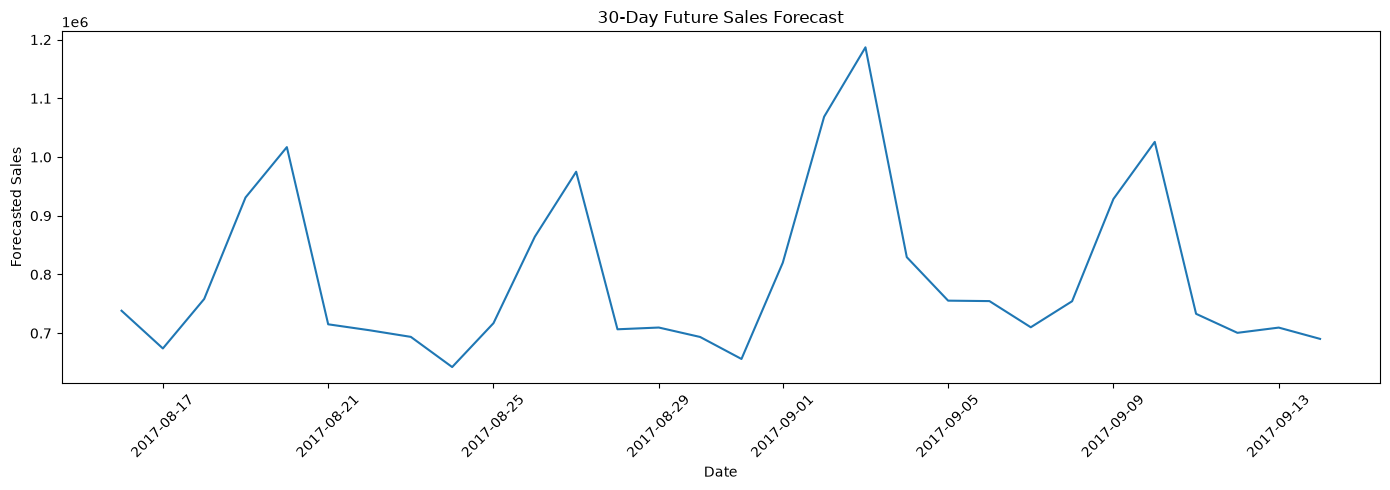

Figure saved successfully.


In [215]:
plt.figure(figsize=(14, 5))

plt.plot(
    future_forecast["date"],
    future_forecast["forecasted_sales"]
)

plt.title("30-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/future_30_day_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Save Forecast Results


In [189]:
future_forecast.to_csv(
    "../outputs/forecasts/30_day_sales_forecast.csv",
    index=False
)

print("30-day forecast saved successfully.")
print("File: outputs/forecasts/30_day_sales_forecast.csv")

30-day forecast saved successfully.
File: outputs/forecasts/30_day_sales_forecast.csv


### Create Final Forecast Summary

In [190]:
print("Forecast Period:")
print(
    future_forecast["date"].min(),
    "to",
    future_forecast["date"].max()
)

print("\nAverage Forecasted Sales:")
print(
    future_forecast["forecasted_sales"].mean()
)

print("\nHighest Forecasted Sales:")
print(
    future_forecast["forecasted_sales"].max()
)

print("\nLowest Forecasted Sales:")
print(
    future_forecast["forecasted_sales"].min()
)

Forecast Period:
2017-08-16 00:00:00 to 2017-09-14 00:00:00

Average Forecasted Sales:
795445.3120250093

Highest Forecasted Sales:
1186865.7008551678

Lowest Forecasted Sales:
642288.3402992629


### Save Model Performance Results

In [191]:
results.to_csv(
    "../outputs/model_performance.csv",
    index=False
)

print("Model performance results saved successfully.")
print("File: outputs/model_performance.csv")

Model performance results saved successfully.
File: outputs/model_performance.csv


### Save Feature Importance Results

In [192]:
feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

print("Feature importance results saved successfully.")
print("File: outputs/feature_importance.csv")

Feature importance results saved successfully.
File: outputs/feature_importance.csv


### Generate Business Insights

In [193]:
# Create a detailed business insights report

insights_data = [
    {
        "Category": "Sales Performance",
        "Metric": "Average Daily Sales",
        "Value": daily_sales["total_sales"].mean(),
        "Unit": "Sales",
        "Business Interpretation": "Represents the average daily retail demand across the historical period."
    },
    {
        "Category": "Sales Performance",
        "Metric": "Highest Daily Sales",
        "Value": daily_sales["total_sales"].max(),
        "Unit": "Sales",
        "Business Interpretation": "Represents the highest recorded daily demand and can help identify peak-demand periods."
    },
    {
        "Category": "Seasonality",
        "Metric": "Highest Sales Day",
        "Value": best_day,
        "Unit": "Day of Week",
        "Business Interpretation": "Indicates the weekday with the strongest average sales and can support weekly inventory and staffing decisions."
    },
    {
        "Category": "Seasonality",
        "Metric": "Highest Sales Month",
        "Value": best_month,
        "Unit": "Month",
        "Business Interpretation": "Indicates the month with the strongest average sales and highlights important seasonal demand."
    },
    {
        "Category": "Model Performance",
        "Metric": "Best Model",
        "Value": "Random Forest",
        "Unit": "Model",
        "Business Interpretation": "Random Forest achieved better forecasting performance than the Linear Regression baseline."
    },
    {
        "Category": "Model Performance",
        "Metric": "Random Forest MAE",
        "Value": mae_rf,
        "Unit": "Sales",
        "Business Interpretation": "Measures the average absolute difference between actual and predicted sales."
    },
    {
        "Category": "Model Performance",
        "Metric": "Random Forest RMSE",
        "Value": rmse_rf,
        "Unit": "Sales",
        "Business Interpretation": "Measures forecasting error while giving greater weight to larger prediction errors."
    },
    {
        "Category": "Model Performance",
        "Metric": "Random Forest MAPE",
        "Value": mape_rf,
        "Unit": "Percentage",
        "Business Interpretation": "Represents the average percentage difference between actual and predicted sales."
    },
    {
        "Category": "Future Forecast",
        "Metric": "Average 30-Day Forecast",
        "Value": future_forecast["forecasted_sales"].mean(),
        "Unit": "Sales",
        "Business Interpretation": "Represents the expected average daily sales over the next 30 forecasted days."
    }
]

insights_df = pd.DataFrame(insights_data)

# Round numerical values for a clean business report
insights_df["Value"] = insights_df["Value"].apply(
    lambda x: round(x, 2) if isinstance(x, (int, float, np.integer, np.floating)) else x
)

print("Detailed Business Insights:")
display(insights_df)

Detailed Business Insights:


,Category,Metric,Value,Unit,Business Interpretation
0,Sales Performance,Average Daily Sales,"637,556.38",Sales,Represents the average daily retail demand acr...
1,Sales Performance,Highest Daily Sales,"1,463,083.96",Sales,Represents the highest recorded daily demand a...
2,Seasonality,Highest Sales Day,Sunday,Day of Week,Indicates the weekday with the strongest avera...
3,Seasonality,Highest Sales Month,12,Month,Indicates the month with the strongest average...
4,Model Performance,Best Model,Random Forest,Model,Random Forest achieved better forecasting perf...
5,Model Performance,Random Forest MAE,"76,821.42",Sales,Measures the average absolute difference betwe...
6,Model Performance,Random Forest RMSE,"133,556.96",Sales,Measures forecasting error while giving greate...
7,Model Performance,Random Forest MAPE,47.50,Percentage,Represents the average percentage difference b...
8,Future Forecast,Average 30-Day Forecast,"795,445.31",Sales,Represents the expected average daily sales ov...


### Save Business Insights

In [194]:
insights = {
    "average_daily_sales": daily_sales["total_sales"].mean(),
    "highest_daily_sales": daily_sales["total_sales"].max(),
    "highest_sales_day": best_day,
    "highest_sales_month": best_month,
    "best_model": "Random Forest",
    "random_forest_mae": mae_rf,
    "random_forest_rmse": rmse_rf,
    "random_forest_mape": mape_rf,
    "average_30_day_forecast": future_forecast["forecasted_sales"].mean()
}

insights_df = pd.DataFrame(
    list(insights.items()),
    columns=["Metric", "Value"]
)

insights_df.to_csv(
    "../outputs/business_insights.csv",
    index=False
)

print("Business insights saved successfully.")
print("File: outputs/business_insights.csv")

Business insights saved successfully.
File: outputs/business_insights.csv


### Export Final Forecast

### Saveing Model for Reuse

In [196]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_sales_model.joblib"
)

print("Random Forest model saved successfully.")
print("File: models/random_forest_sales_model.joblib")

Random Forest model saved successfully.
File: models/random_forest_sales_model.joblib


### Save Required Model Features

In [197]:
import json

with open("../models/model_features.json", "w") as file:
    json.dump(features, file, indent=4)

print("Model features saved successfully.")
print("File: models/model_features.json")

Model features saved successfully.
File: models/model_features.json


### Create Project Output Summary

In [198]:
print("Project Outputs")
print("-" * 40)

print("✓ Model performance results")
print("✓ Feature importance results")
print("✓ Business insights")
print("✓ 30-day sales forecast")
print("✓ Random Forest model")
print("✓ Model feature list")

print("\nTask 1 analysis and forecasting workflow completed.")

Project Outputs
----------------------------------------
✓ Model performance results
✓ Feature importance results
✓ Business insights
✓ 30-day sales forecast
✓ Random Forest model
✓ Model feature list

Task 1 analysis and forecasting workflow completed.


### Prepare Notebook for GitHub

In [199]:
print("Notebook preparation completed.")
print("All major analysis, modeling, evaluation, forecasting, and output steps are included.")
print("Ready for final project documentation and GitHub upload.")

Notebook preparation completed.
All major analysis, modeling, evaluation, forecasting, and output steps are included.
Ready for final project documentation and GitHub upload.


### Create Project Requirements File

In [200]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [201]:
from importlib.metadata import version

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "openpyxl",
    "joblib"
]

with open("../requirements.txt", "w") as file:
    for package in packages:
        file.write(f"{package}=={version(package)}\n")

print("requirements.txt created successfully.")

requirements.txt created successfully.


### Creating GitHub .gitignore

In [202]:
gitignore_content = """# Python
__pycache__/
*.py[cod]
.venv/
venv/

# Jupyter
.ipynb_checkpoints/

# Dataset files
data/raw/*.csv

# Generated model files
models/*.joblib

# Generated outputs
outputs/*.csv
outputs/forecasts/*.csv

# VS Code
.vscode/
"""

with open("../.gitignore", "w") as file:
    file.write(gitignore_content)

print(".gitignore created successfully.")

.gitignore created successfully.
